In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from codec import DataCodec


>>> Аналіз файлу: tests_samples\smaragdove_nebo.txt

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 440 bytes
  Ratio: 2.000x
  Compress time: 0.14 ms
  Decompress time: 0.17 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 244 bytes
  Ratio: 1.109x
  Compress time: 0.20 ms
  Decompress time: 0.27 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 225 bytes
  Ratio: 1.023x
  Compress time: 2.12 ms
  Decompress time: 1.80 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 165 bytes
  Ratio: 0.750x
  Compress time: 0.41 ms
  Decompress time: 0.29 ms


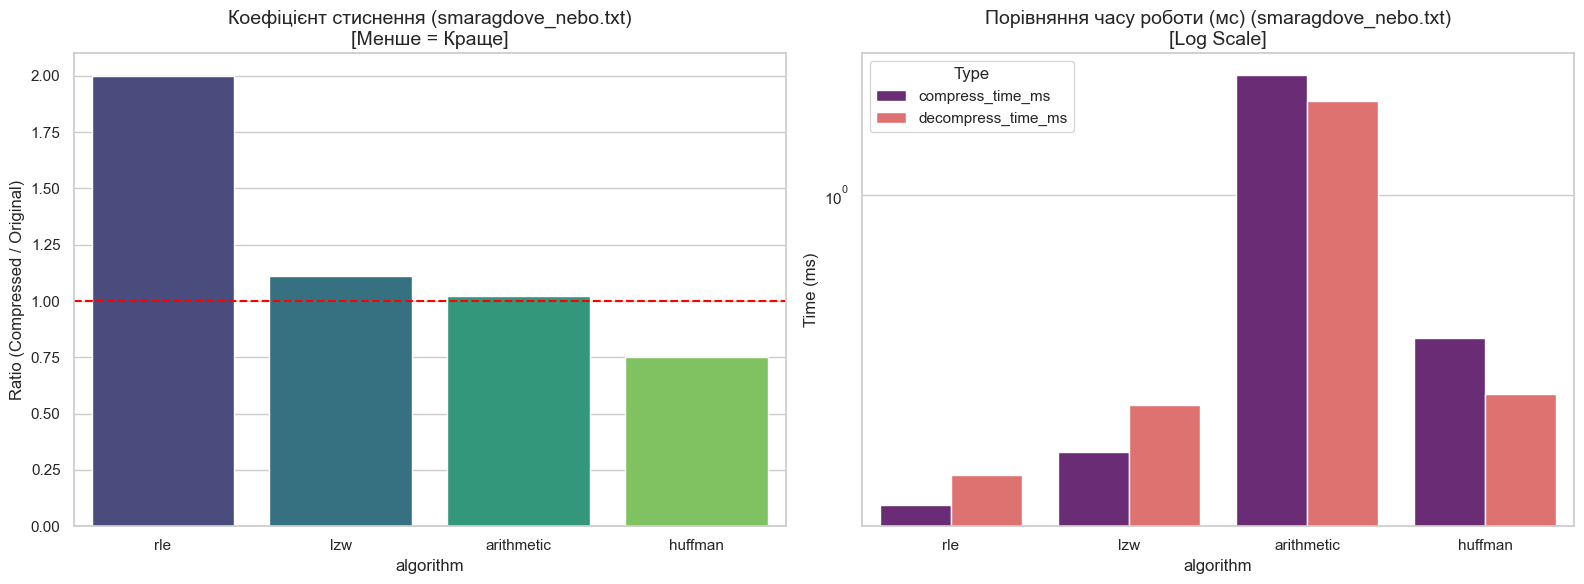

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,rle,2.000000,0.142813,0.171661,True
1,lzw,1.109091,0.198603,0.267506,True
2,arithmetic,1.022727,2.118111,1.798630,True
3,huffman,0.750000,0.405788,0.286818,True



>>> Аналіз файлу: tests_samples\iced_oatmilk_latte.jpg

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 119,820 bytes
  Ratio: 1.982x
  Compress time: 15.04 ms
  Decompress time: 23.96 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 92,418 bytes
  Ratio: 1.529x
  Compress time: 47.91 ms
  Decompress time: 34.43 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 60,547 bytes
  Ratio: 1.002x
  Compress time: 388.87 ms
  Decompress time: 441.30 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 60,881 bytes
  Ratio: 1.007x
  Compress time: 154.74 ms
  Decompress time: 121.24 ms


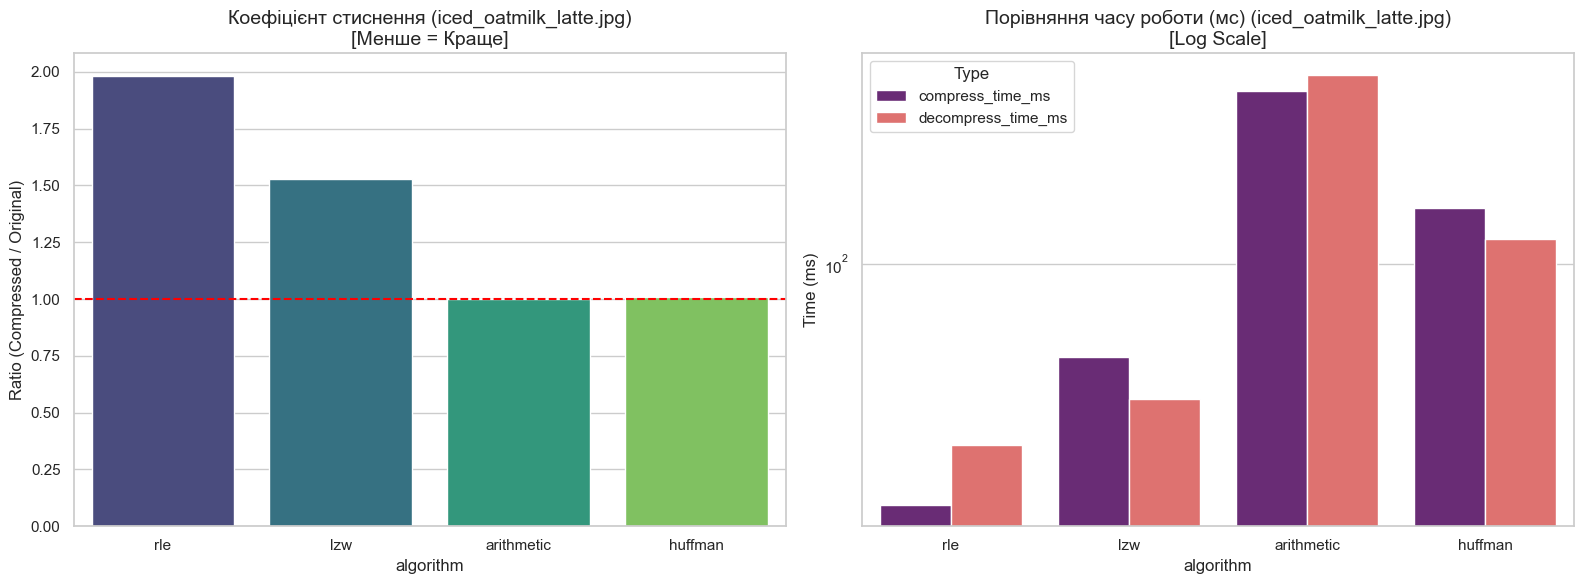

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,rle,1.982298,15.035391,23.957253,True
1,lzw,1.528960,47.911406,34.428120,True
2,arithmetic,1.001687,388.868570,441.300631,True
3,huffman,1.007213,154.735327,121.240854,True



>>> Аналіз файлу: tests_samples\sound.wav

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 6,840,840 bytes
  Ratio: 1.860x
  Compress time: 981.94 ms
  Decompress time: 1400.79 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 3,678,286 -> 3,163,818 bytes
  Ratio: 0.860x
  Compress time: 3001.83 ms
  Decompress time: 1650.99 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,353,196 bytes
  Ratio: 0.912x
  Compress time: 20505.91 ms
  Decompress time: 20802.56 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,362,231 bytes
  Ratio: 0.914x
  Compress time: 4695.93 ms
  Decompress time: 5852.99 ms


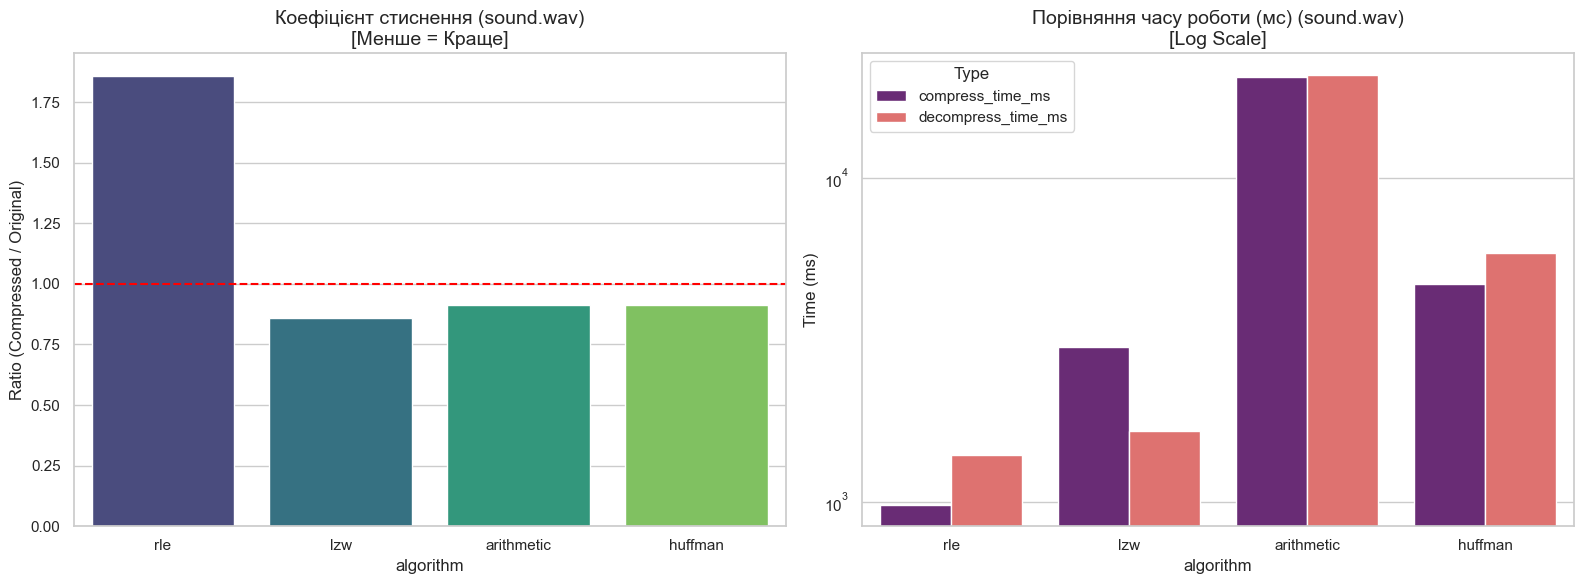

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,rle,1.859790,981.942654,1400.788069,True
1,lzw,0.860134,3001.826286,1650.987625,False
2,arithmetic,0.911619,20505.908966,20802.560568,True
3,huffman,0.914075,4695.931196,5852.988958,True


In [ ]:
def visualize_results(df, title_suffix=""):
    """
    Функція для побудови графіків аналізу.
    title_suffix: додає назву файлу до заголовка (напр. 'для тексту' або 'для аудіо')
    """
    if df.empty:
        print("Немає даних для візуалізації.")
        return

    # Розраховуємо швидкість обробки (Throughput) в КБ/с для цікавості
    df['throughput_kb_s'] = (df['original_size'] / 1024) / (df['compress_time_ms'] / 1000)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Графік Коефіцієнта стиснення (Ratio)
    sns.barplot(
        x='algorithm', y='ratio', data=df, ax=axes[0],
        palette='viridis', hue='algorithm', legend=False
    )
    axes[0].set_title(f'Коефіцієнт стиснення {title_suffix}\n[Менше = Краще]', fontsize=14)
    axes[0].axhline(1, color='red', linestyle='--', label='Межа (1.0)')
    axes[0].set_ylabel('Ratio (Compressed / Original)')

    # 2. Графік Часу (Log scale)
    df_time = df.melt(
        id_vars='algorithm',
        value_vars=['compress_time_ms', 'decompress_time_ms'],
        var_name='Type', value_name='Time_ms'
    )

    sns.barplot(
        x='algorithm', y='Time_ms', hue='Type', data=df_time,
        ax=axes[1], palette='magma'
    )
    axes[1].set_title(f'Порівняння часу роботи (мс) {title_suffix}\n[Log Scale]', fontsize=14)
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Time (ms)')

    plt.tight_layout()
    plt.show()

def run_full_analysis(file_paths):
    """
    Проганяє тести для списку файлів і будує графіки для кожного.
    """
    codec = DataCodec()
    algorithms = ['rle', 'lzw', 'arithmetic', 'huffman']

    for path in file_paths:
        if not os.path.exists(path):
            print(f"Файл {path} не знайдено, пропускаємо.")
            continue

        results = []
        print(f"\n>>> Аналіз файлу: {path}")

        for algo in algorithms:
            try:
                res = codec.test_algorithm(path, algo)
                if res: results.append(res)
            except Exception as e:
                print(f"Помилка {algo}: {e}")

        df = pd.DataFrame(results)
        file_name = os.path.basename(path)
        visualize_results(df, title_suffix=f"({file_name})")

        # Виводимо коротку таблицю під графіками
        display(df[['algorithm', 'ratio', 'compress_time_ms', 'decompress_time_ms', 'is_valid']])

# Виклик аналізу для різних типів файлів
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "sound.wav")
]

run_full_analysis(files_to_test)